# Classical search algorithms for tic-tac-toe

Milestone 0.5 of the [MCTS and AlphaZero project](https://github.com/gpsaggese/gpsaggese.github.io/blob/master/research/ideas/draft.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.md): the search algorithms MCTS grew out of (Lesson09.8), run on the same `Game` interface as `mcts.example.ipynb`.

- Minimax and alpha-beta pruning: exact, exhaustive search
- Depth-limited search: exact search cut at a fixed depth, scored by a
  hand-built evaluation function
- Flat Monte Carlo: no evaluation function, each action scored by
  averaging random playouts instead
- Each section shows the search tree the algorithm actually builds, since
  (Lesson09.8) "the shape of the tree is the allocation of the budget"
- `search_algorithms_utils.py` implements all four against
  `mcts_utils.Game`; `game_examples.py` supplies `TicTacToe` and the
  evaluation function; see `README.md` for a description of every file in
  this directory

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging
from typing import cast

import helpers.hdbg as hdbg
import helpers.hnotebook as hnotebook

_LOG = logging.getLogger(__name__)

hdbg.init_logger(verbosity=logging.INFO)
hnotebook.config_notebook()

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

INFO  > /Users/saggese/src/venv/client_venv.helpers/lib/python3.11/site-packages/ipykernel_launcher.py -f /private/var/folders/pd/0_nppqrn3cn7936mmhk37gcw0000gn/T/tmpooetns8p.json --HistoryManager.hist_file=:memory:


In [2]:
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.game_examples as rimtsaazge
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.mcts_utils as rimtsaazmu
import research.Implement_MonteCarlo_Tree_Search_and_Alpha_Zero.search_algorithms_utils as rimtsaazsau

# Part 2: The game

Same `TicTacToe` as `mcts.example.ipynb`: legal moves, applying a move,
checking for a winner, whose turn it is, and rendering the board. All four
algorithms below only call these six methods, so any other `Game` (Connect
Four, say) would plug in unchanged.

## Cell 2.1: An empty board

In [3]:
game = rimtsaazge.TicTacToe()
print(game.render(game.get_initial_state()))

. . .
. . .
. . .


We reuse two fixed positions throughout this notebook so every algorithm
is compared on the same ground:
- `demo_state`: the same position as `mcts.example.ipynb` Cell 3.1 -- X
  already has two in a row, playing cell 2 wins immediately
- `fork_state`: X opens in a corner, O blunders to an edge -- X now has a
  forced win by forking two lines at once, but only if the search looks
  far enough ahead to see it (used in Part 5)

In [4]:
demo_state = (1, 1, 0, -1, -1, 0, 0, 0, 0)
fork_state = (1, -1, 0, 0, 0, 0, 0, 0, 0)
print("demo_state:")
print(game.render(demo_state))
print()
print("fork_state:")
print(game.render(fork_state))

demo_state:
X X .
O O .
. . .

fork_state:
X O .
. . .
. . .


# Part 3: Minimax

## Cell 3.1: Minimax finds the winning move

Lesson09.8: "minimax computes the value of a state by backing terminal
values up the tree ... returns the optimal action when the whole tree is
searched and both players play optimally." `build_minimax_tree()` visits
every node reachable from `demo_state`; the diagram below renders the
root plus 2 levels, colored by what each node turned out to be (blue:
explored internal node; green: explored terminal node).

minimax move: 2
minimax root value Q(s0): 1.0
nodes explored: 157


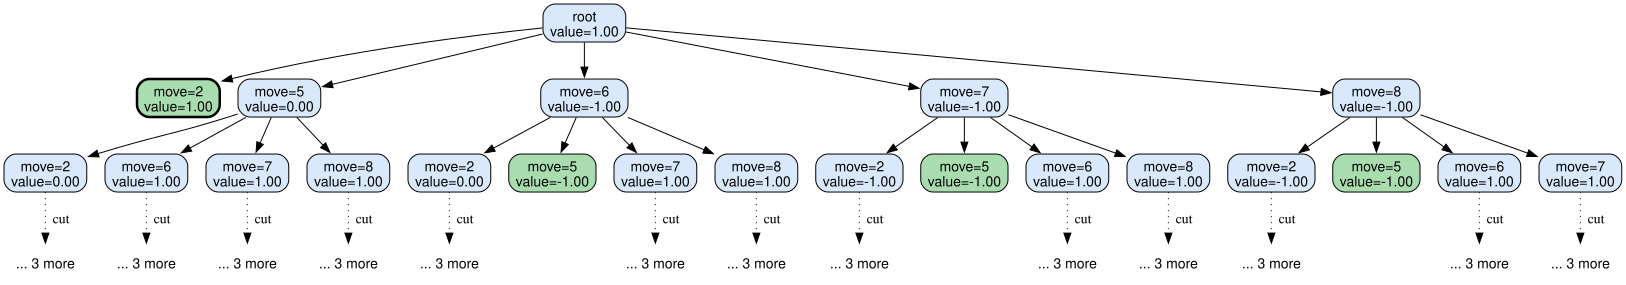

In [5]:
minimax_root = rimtsaazsau.build_minimax_tree(game, demo_state)
minimax_move = rimtsaazsau.pick_best_move(game, minimax_root)
print("minimax move:", minimax_move)
print("minimax root value Q(s0):", minimax_root.value)
print("nodes explored:", minimax_root.node_count)

display(
    rimtsaazsau.build_tree_graph(
        minimax_root, best_move=minimax_move, max_depth=2
    )
)

**Key observations**:
- Minimax finds the same winning move (cell 2) that MCTS found in
  `mcts.example.ipynb` Cell 3.1 -- unsurprising, both are searching the
  same exact game, MCTS just estimates the same values by sampling
- Every one of the `node_count` nodes above was actually visited: Lesson09.8's
  "a full minimax search costs `O(b^d)` since it requires the entire
  search tree to be built"

# Part 4: Alpha-Beta Pruning

## Cell 4.1: The same move, far fewer nodes

Lesson09.8: "Alpha-beta pruning skips branches that are proven worse than
a move already found, stop exploring it." `alpha` / `beta` are the best
values the maximizing / minimizing player can already guarantee; once
`alpha >= beta`, the remaining siblings at that node cannot change the
result and are recorded as **pruned** (grey, dashed) instead of explored.

alpha-beta move: 2
alpha-beta root value Q(s0): 1.0
nodes recorded: 60  nodes explored: 36  (vs. minimax's 157 )


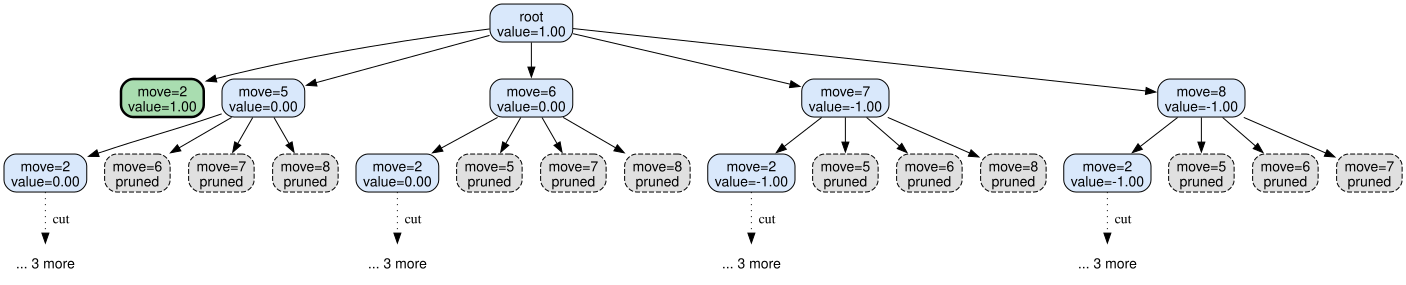

In [6]:
alpha_beta_root = rimtsaazsau.build_alpha_beta_tree(game, demo_state)
alpha_beta_move = rimtsaazsau.pick_best_move(game, alpha_beta_root)
print("alpha-beta move:", alpha_beta_move)
print("alpha-beta root value Q(s0):", alpha_beta_root.value)
print(
    "nodes recorded:",
    alpha_beta_root.node_count,
    " nodes explored:",
    alpha_beta_root.num_explored_nodes,
    " (vs. minimax's",
    minimax_root.node_count,
    ")",
)

display(
    rimtsaazsau.build_tree_graph(
        alpha_beta_root, best_move=alpha_beta_move, max_depth=2
    )
)

**Key observations**:
- Same move, same value as Part 3's exact minimax -- alpha-beta is exact,
  it only skips work that provably cannot change the answer
- The grey, dashed nodes above were never explored: their subtree was
  pruned once an earlier sibling already proved worse-or-equal for one
  side
- The root's own children are never pruned (there is no earlier sibling
  to compare against yet), which is why `run_alpha_beta()` always agrees
  with `run_minimax()` on the move to play

## Cell 4.2: The saving compounds with the tree size

`demo_state` only has 5 empty cells. Running both algorithms from the
**empty** board -- the full tic-tac-toe game tree -- makes Lesson09.8's
"the cost can drop to `O(b^{d/2})`, which doubles the reachable depth"
concrete.

In [7]:
import time

empty_state = game.get_initial_state()

t0 = time.time()
minimax_empty_root = rimtsaazsau.build_minimax_tree(game, empty_state)
minimax_empty_time = time.time() - t0

t0 = time.time()
alpha_beta_empty_root = rimtsaazsau.build_alpha_beta_tree(game, empty_state)
alpha_beta_empty_time = time.time() - t0

print(
    f"minimax:    {minimax_empty_root.node_count:>7} nodes,"
    f" {minimax_empty_time:5.2f} s, value={minimax_empty_root.value}"
)
print(
    f"alpha-beta: {alpha_beta_empty_root.num_explored_nodes:>7} nodes,"
    f" {alpha_beta_empty_time:5.2f} s, value={alpha_beta_empty_root.value}"
)
speedup = minimax_empty_root.node_count / alpha_beta_empty_root.num_explored_nodes
print(f"node-count speedup: {speedup:.1f}x")

minimax:     549946 nodes,  3.90 s, value=0.0
alpha-beta:   18297 nodes,  0.13 s, value=0.0
node-count speedup: 30.1x


**Key observations**:
- Both agree the empty board is a draw (`value=0.0`): with correct play,
  tic-tac-toe always ends in a draw, no matter which cell X opens with
- Alpha-beta visits an order of magnitude fewer nodes for the identical
  answer -- pure overhead removed, nothing traded away

# Part 5: Depth-Limited Search

## Cell 5.1: The evaluation function

Lesson09.8: depth-limited search "cuts the search at a fixed depth" and
"replaces the true value of a not-terminal state with a heuristic
estimate. Every cut node must be scored by a hand-built evaluation
function." `game_examples.evaluate_tic_tac_toe()` counts, over the 8 win
lines, how many are still open for each player and returns the normalized
difference -- a local, cheap feature, per Lesson09.8's chess-evaluation
example.

It is also an imperfect one: it scores each line independently, so it
cannot see a **fork** (two lines sharing an empty cell, so the opponent
cannot block both). `demo_state` already shows the gap -- X has an
immediate winning move there, yet the heuristic alone rates the position
as slightly *bad* for X.

In [8]:
print("evaluate_tic_tac_toe(empty_state):", rimtsaazge.evaluate_tic_tac_toe(empty_state))
print("evaluate_tic_tac_toe(demo_state): ", rimtsaazge.evaluate_tic_tac_toe(demo_state))
print("evaluate_tic_tac_toe(fork_state): ", rimtsaazge.evaluate_tic_tac_toe(fork_state))

evaluate_tic_tac_toe(empty_state): 0.0
evaluate_tic_tac_toe(demo_state):  -0.125
evaluate_tic_tac_toe(fork_state):  0.125


## Cell 5.2: A cut that is too shallow misses the fork

From `fork_state`, exact minimax finds a forced win (`value=1.0`) by
playing cell 3. A 1-ply depth-limited search cannot see that far: it
scores each immediate reply by the heuristic alone and picks the center
instead. The tree below shows why -- every leaf is an amber,
heuristically-scored cut, not an exact outcome.

exact minimax move on fork_state: 3
depth-limited (max_depth=1) move: 4


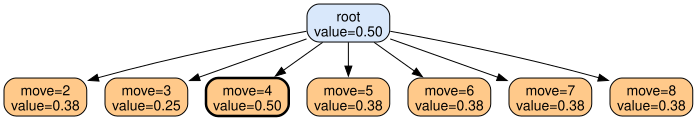

In [9]:
minimax_fork_move = rimtsaazsau.pick_best_move(
    game, rimtsaazsau.build_minimax_tree(game, fork_state)
)
print("exact minimax move on fork_state:", minimax_fork_move)

depth_limited_root = rimtsaazsau.build_depth_limited_tree(
    game, fork_state, rimtsaazge.evaluate_tic_tac_toe, max_depth=1
)
depth_limited_move = rimtsaazsau.pick_best_move(game, depth_limited_root)
print("depth-limited (max_depth=1) move:", depth_limited_move)

display(
    rimtsaazsau.build_tree_graph(
        depth_limited_root, best_move=depth_limited_move, max_depth=1
    )
)

## Cell 5.3: Search deep enough and the fork reappears

Growing `max_depth` trades cost for correctness: at some depth the fork
falls inside the search horizon and depth-limited search recovers
minimax's exact answer, without ever changing the evaluation function.

In [10]:
for max_depth in range(1, 6):
    root = rimtsaazsau.build_depth_limited_tree(
        game, fork_state, rimtsaazge.evaluate_tic_tac_toe, max_depth=max_depth
    )
    move = rimtsaazsau.pick_best_move(game, root)
    match = "matches minimax" if move == minimax_fork_move else "differs"
    print(
        f"max_depth={max_depth}: move={move}, value={root.value:.3f},"
        f" nodes={root.node_count}  ({match})"
    )

max_depth=1: move=4, value=0.500, nodes=8  (differs)
max_depth=2: move=4, value=0.125, nodes=50  (differs)
max_depth=3: move=6, value=0.375, nodes=260  (differs)
max_depth=4: move=2, value=0.000, nodes=1020  (differs)
max_depth=5: move=3, value=1.000, nodes=3192  (matches minimax)


**Key observations**:
- The chosen move is not even monotonic in `max_depth`: Lesson09.8's
  "the result inherits that estimate's bias" -- a bit more lookahead can
  change which bias dominates before the search is deep enough to be exact
- Once `max_depth` reaches the fork, depth-limited search matches exact
  minimax while still visiting far fewer nodes than searching to the end
  of the game every time

# Part 6: Flat Monte Carlo

## Cell 6.1: Scoring actions by simulation instead of by heuristic

Lesson09.8: "for each action `a` at `s0`, run `N` random playouts to a
terminal state, estimate `Q_hat(s0, a)` as the mean terminal outcome,
play `argmax_a Q_hat(s0, a)`." No evaluation function is needed -- the
terminal outcome is exact, only the playout policy (uniform random,
reused from `mcts_utils.random_rollout()`) introduces bias. The resulting
tree has exactly one level: "flat Monte Carlo is exactly MCTS with a
tree of depth one."

flat Monte Carlo move: 2
  move=2  Q_hat=+1.000
  move=5  Q_hat=+0.287
  move=6  Q_hat=-0.097
  move=7  Q_hat=-0.373
  move=8  Q_hat=-0.387


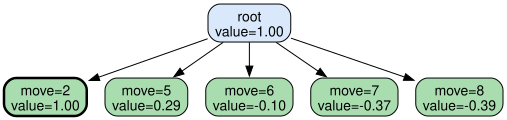

In [11]:
import random

random.seed(0)
flat_mc_root = rimtsaazsau.build_flat_mc_tree(game, demo_state, num_rollouts=300)
flat_mc_move = rimtsaazsau.pick_best_move(game, flat_mc_root)
print("flat Monte Carlo move:", flat_mc_move)
for child in sorted(
    flat_mc_root.children,
    key=lambda child: cast(float, child.value),
    reverse=True,
):
    print(f"  move={child.move}  Q_hat={child.value:+.3f}")

display(
    rimtsaazsau.build_tree_graph(
        flat_mc_root, best_move=flat_mc_move, max_depth=1
    )
)

**Key observations**:
- `Q_hat` for the winning move (cell 2) is close to `+1.0`: almost every
  random rollout through it ends in a win, since the win is immediate
- The other actions get noisier, spread-out estimates -- exactly
  Lesson09.8's "flat Monte Carlo ... spreads the simulation budget
  uniformly," with no tree to concentrate it on the promising line

# Part 7: Comparing All Four (Plus MCTS)

## Cell 7.1: Same position, four families of search

One more run of MCTS on `demo_state` (as in `mcts.example.ipynb` Cell
3.1) closes the loop: every method below answers the same question --
which move is best from `demo_state` -- with a different budget and a
different source of information.

In [12]:
import pandas as pd

random.seed(0)
mcts_root = rimtsaazmu.build_mcts_tree(game, demo_state, num_simulations=200)
mcts_move = max(
    mcts_root.children.items(), key=lambda item: item[1].visit_count
)[0]
# `mcts_root.mean_value` is from the perspective of the (nonexistent) player
# who "moved into" the root, i.e., the opponent of whoever is to move at
# `demo_state`; the chosen child's `mean_value` is the one in the mover's
# own perspective, comparable to the other four algorithms' `value` below
# (same convention `mcts_API_utils.py`'s comment panel uses for `Q(s, a)`).
mcts_value = mcts_root.children[mcts_move].mean_value

comparison = pd.DataFrame(
    [
        {
            "algorithm": "Minimax",
            "move": minimax_move,
            "value": minimax_root.value,
            "nodes/rollouts/sims": minimax_root.node_count,
            "evaluation function": "none (exact)",
        },
        {
            "algorithm": "Alpha-beta pruning",
            "move": alpha_beta_move,
            "value": alpha_beta_root.value,
            "nodes/rollouts/sims": alpha_beta_root.num_explored_nodes,
            "evaluation function": "none (exact)",
        },
        {
            "algorithm": "Depth-limited search (max_depth=1)",
            "move": depth_limited_move,
            "value": round(cast(float, depth_limited_root.value), 3),
            "nodes/rollouts/sims": depth_limited_root.node_count,
            "evaluation function": "evaluate_tic_tac_toe (heuristic)",
        },
        {
            "algorithm": "Flat Monte Carlo",
            "move": flat_mc_move,
            "value": round(cast(float, flat_mc_root.value), 3),
            "nodes/rollouts/sims": "300 rollouts/move",
            "evaluation function": "none (random playouts)",
        },
        {
            "algorithm": "MCTS",
            "move": mcts_move,
            "value": round(mcts_value, 3),
            "nodes/rollouts/sims": "200 simulations",
            "evaluation function": "none (random playouts + tree)",
        },
    ]
)
display(comparison)

,algorithm,move,value,nodes/rollouts/sims,evaluation function
0,Minimax,2,1.0,157,none (exact)
1,Alpha-beta pruning,2,1.0,36,none (exact)
2,Depth-limited search (max_depth=1),4,0.5,8,evaluate_tic_tac_toe (heuristic)
3,Flat Monte Carlo,2,1.0,300 rollouts/move,none (random playouts)
4,MCTS,2,1.0,200 simulations,none (random playouts + tree)


**Key observations** (Lesson09.8, "MCTS vs Exhaustive Search" /
"MCTS vs Pure Monte Carlo Simulation"):
- All five agree on the move here -- the win is one ply away, easy for
  every method to find -- but they get there through very different node
  coverage: minimax/alpha-beta cover the position uniformly to the end of
  the game, MCTS and flat MC sample it, and depth-limited search cuts it
  short and patches the cut with domain knowledge
- Only depth-limited search needs a hand-built evaluation function;
  the other four need only the rules and, for MCTS/flat MC, a random
  simulator
- MCTS is the only one of the four sampling/tree methods that reuses
  statistics across simulations to steer where the *next* simulation
  goes -- flat MC's playouts are independent of each other, which is why
  its tree above stops at depth one

# Part 8: Full-Game Sanity Check

## Cell 8.1: Each player actually plays tic-tac-toe correctly

A quick end-to-end check that `make_alpha_beta_player()`,
`make_depth_limited_player()`, and `make_flat_mc_player()` are usable
with `mcts_utils.play_game()` exactly like `make_mcts_player()` in
`mcts.example.ipynb`. Raw minimax is skipped here: unlike alpha-beta, it
has to fully search the ~550,000-node game tree from the *empty* board on
its very first move (Part 4.2), and it would pay that cost again on every
later move too -- Lesson09.8's "the cost is still exponential in `d`"
even though alpha-beta, searching the same tree, does not.

In [13]:
alpha_beta_player = rimtsaazsau.make_alpha_beta_player()
depth_limited_player = rimtsaazsau.make_depth_limited_player(
    rimtsaazge.evaluate_tic_tac_toe, max_depth=2
)
flat_mc_player = rimtsaazsau.make_flat_mc_player(num_rollouts=100)

for name, player in [
    ("alpha-beta", alpha_beta_player),
    ("depth-limited", depth_limited_player),
    ("flat Monte Carlo", flat_mc_player),
]:
    winner, _ = rimtsaazmu.play_game(game, player, rimtsaazmu.random_player)
    print(f"{name:>17} (X) vs. random (O): winner={winner}")

       alpha-beta (X) vs. random (O): winner=1
    depth-limited (X) vs. random (O): winner=1
 flat Monte Carlo (X) vs. random (O): winner=1


**Key observations**:
- Every player finishes a legal game and (with correct play against a
  uniformly random opponent) never loses, same as MCTS in
  `mcts.example.ipynb` Part 4
- Getting a player from any of these algorithms is a one-line
  `make_*_player()` call, since all four -- and MCTS -- share the same
  `(game, state) -> move` signature `play_game()` expects